4. Problem Statement
A car dealership wants to better understand what factors influence car prices and vehicle popularity in the market.
As a Data Analyst, your task is to perform Exploratory Data Analysis (EDA) on the dataset to:
Understand the structure of the dataset
Clean and preprocess the data
Identify patterns and relationships between variables
Detect anomalies and outliers
Analyze which car features influence MSRP (price) and fuel efficiency
Your analysis should help answer questions such as:
Do powerful engines lead to higher car prices?
Does vehicle size affect fuel efficiency?
Are luxury cars significantly more expensive?
Is there a relationship between popularity and price?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/sample_data/Car Features and MSRP data.csv")
df.head()


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
df.shape

(11914, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [6]:
df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


In [7]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Market Category,3742


In [8]:
# If only a few rows have missing values:
df.dropna(inplace=True)


In [9]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,8084.000000,8084.000000,8084.000000,8084.000000,8084.000000,8084.000000,8084.000000,8.084000e+03
mean,2012.058634,274.642751,5.778080,3.414151,26.650915,19.553686,1499.397823,5.007267e+04
std,6.317981,115.003475,1.886088,0.898087,7.720473,7.159964,1413.855615,7.029313e+04
min,1990.000000,55.000000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2010.000000,192.000000,4.000000,2.000000,22.000000,16.000000,549.000000,2.591875e+04
50%,2015.000000,264.000000,6.000000,4.000000,26.000000,18.000000,1013.000000,3.500500e+04
75%,2016.000000,320.000000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.872250e+04
max,2017.000000,1001.000000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [10]:
df.nunique()

,0
Make,47
Model,713
Year,28
Engine Fuel Type,8
Engine HP,327
Engine Cylinders,9
Transmission Type,5
Driven_Wheels,4
Number of Doors,3
Market Category,70


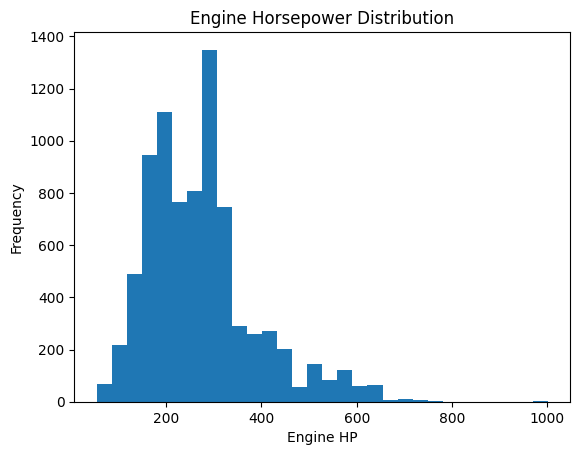

In [11]:
# Univariate Analysis examines one variable at a time

# Engine Horsepower Distribution

plt.hist(df['Engine HP'].dropna(), bins=30)

plt.title("Engine Horsepower Distribution")
plt.xlabel("Engine HP")
plt.ylabel("Frequency")

plt.show()

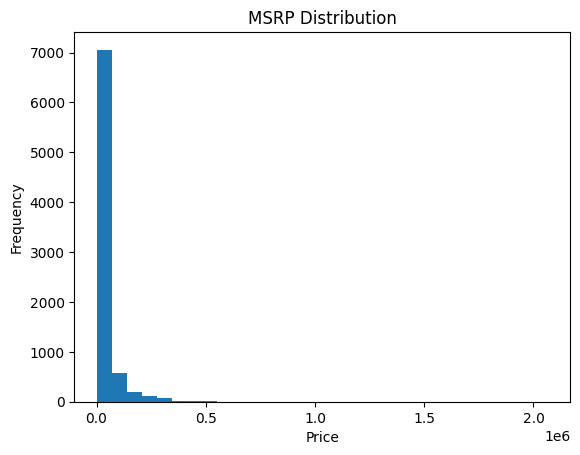

In [13]:
# MSRP Distribution
plt.hist(df['MSRP'], bins=30)

plt.title("MSRP Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

Make


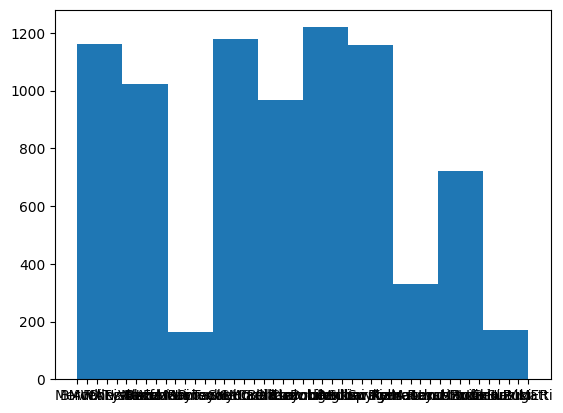

Model


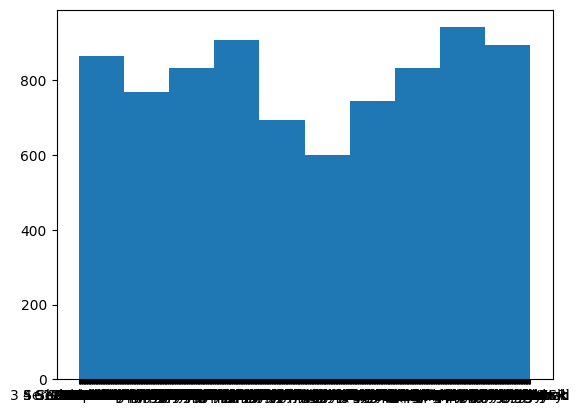

Year


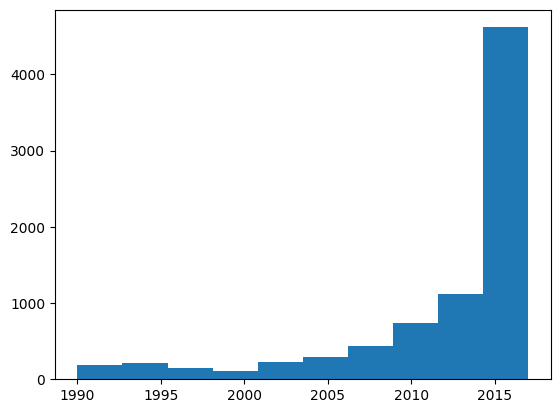

Engine Fuel Type


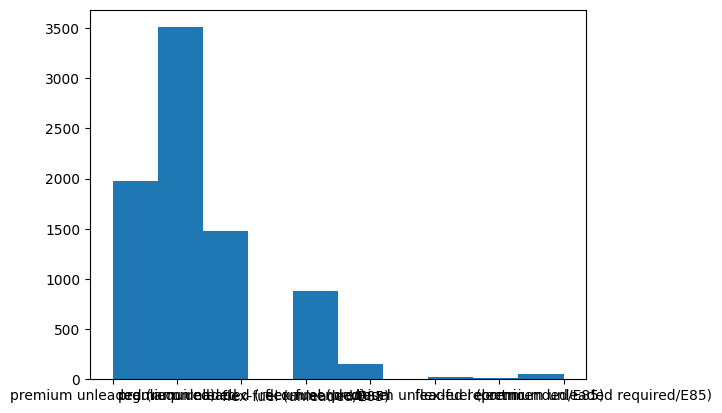

Engine HP


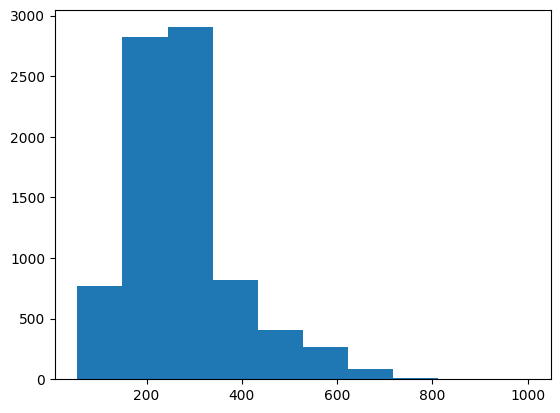

Engine Cylinders


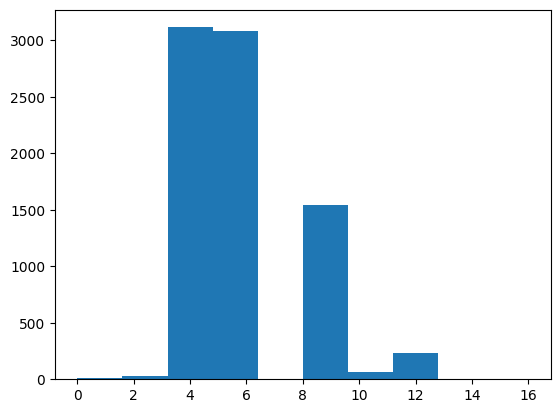

Transmission Type


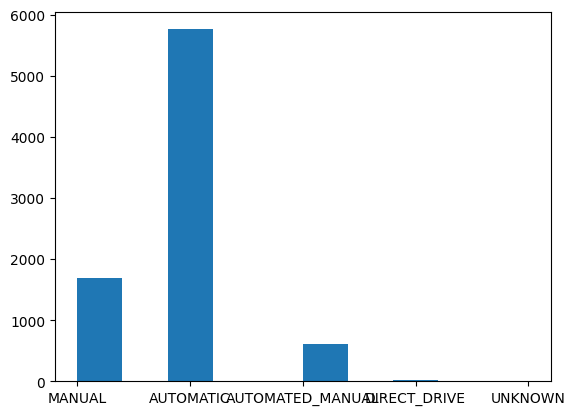

Driven_Wheels


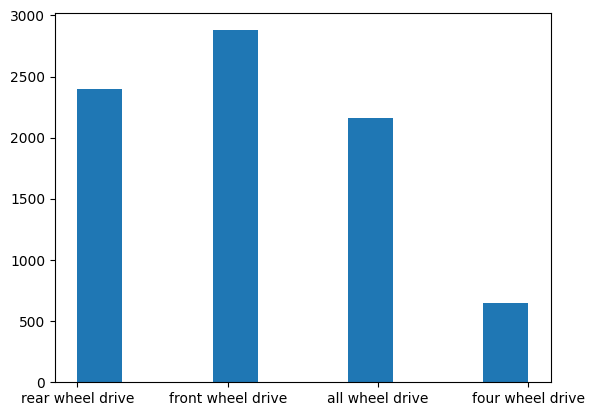

Number of Doors


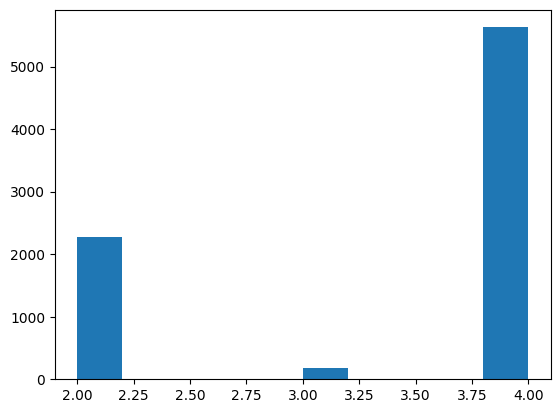

Market Category


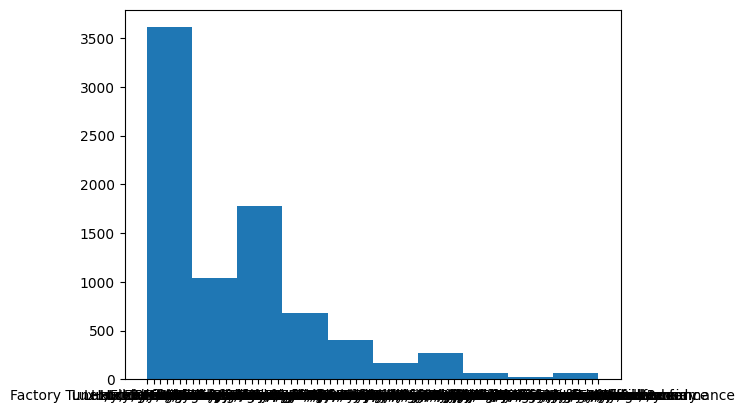

Vehicle Size


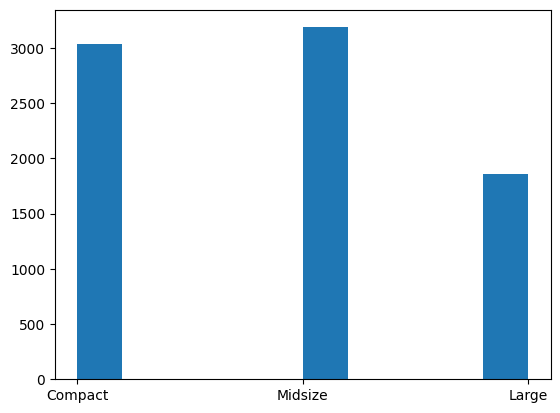

Vehicle Style


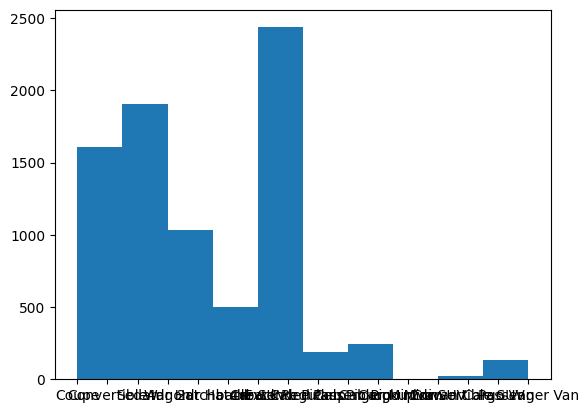

highway MPG


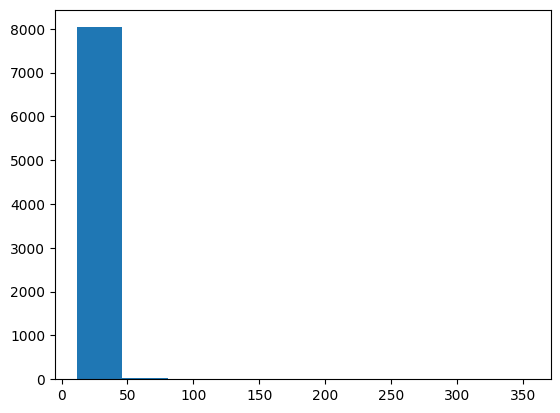

city mpg


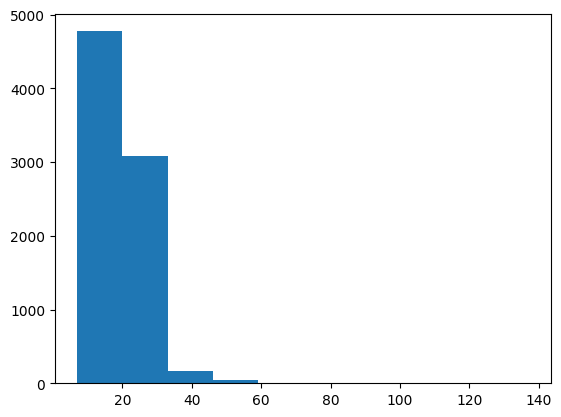

Popularity


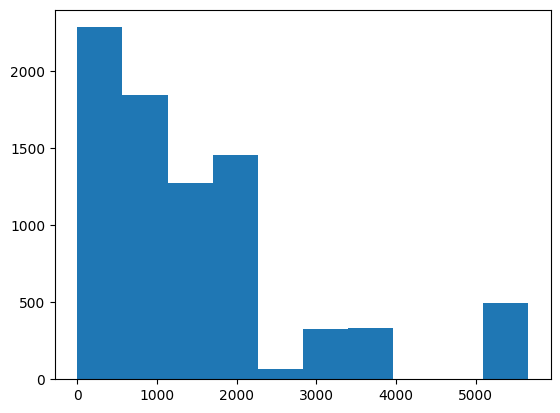

MSRP


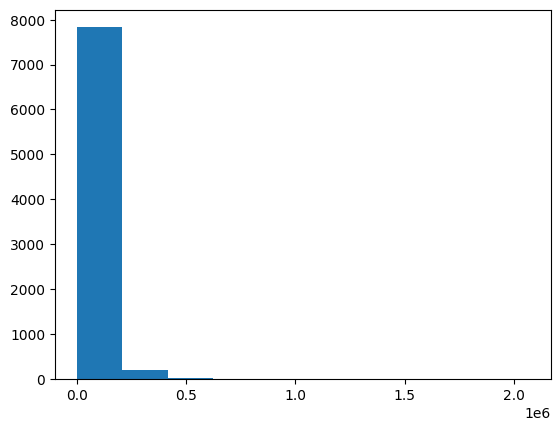

In [14]:
for i in df:
  print(i)
  plt.hist(df[i])
  plt.show()

In [42]:
df.columns

Index(['Make', 'Model', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders',
       'Transmission Type', 'Driven_Wheels', 'Number of Doors',
       'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG',
       'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

In [15]:
# Bivariate analysis

df.corr(numeric_only=True)

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
Year,1.000000,0.244256,-0.046552,0.182905,0.216441,0.180041,0.118304,0.133684
Engine HP,0.244256,1.000000,0.811390,-0.196042,-0.473019,-0.512779,0.038012,0.656662
Engine Cylinders,-0.046552,0.811390,1.000000,-0.178578,-0.603237,-0.615459,0.014825,0.589185
Number of Doors,0.182905,-0.196042,-0.178578,1.000000,0.103413,0.140205,-0.040450,-0.184699
highway MPG,0.216441,-0.473019,-0.603237,0.103413,1.000000,0.821349,0.032504,-0.257585
city mpg,0.180041,-0.512779,-0.615459,0.140205,0.821349,1.000000,0.037057,-0.268003
Popularity,0.118304,0.038012,0.014825,-0.040450,0.032504,0.037057,1.000000,-0.052477
MSRP,0.133684,0.656662,0.589185,-0.184699,-0.257585,-0.268003,-0.052477,1.000000


In [20]:
# Interquartile Range (IQR) is a statistical method used to detect outliers. It measures the spread of the middle 50% of the data.

# Q1 (25th percentile) = First Quartile
# Q3 (75th percentile) = Third Quartile

# Outlier limits are calculated as:

# Lower Limit = Q1 − 1.5 × IQR
# Upper Limit = Q3 + 1.5 × IQR


Q1 = df['MSRP'].quantile(0.25)
Q3 = df['MSRP'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)


Q1 : 25918.75
Q3 : 48722.5
IQR : 22803.75
Lower Limit : -8286.875
Upper Limit : 82928.125


In [24]:
# Find Outliers

outliers = df[(df['MSRP'] < lower_limit) | (df['MSRP'] > upper_limit)]
print("Number of Outliers:", outliers.shape[0])
outliers[['Make', 'Model', 'MSRP']].head(10)

Number of Outliers: 840


,Make,Model,MSRP
294,Ferrari,360,160829
295,Ferrari,360,140615
296,Ferrari,360,150694
297,Ferrari,360,170829
298,Ferrari,360,165986
299,Ferrari,360,154090
300,Ferrari,360,143860
301,Ferrari,360,176287
302,Ferrari,360,157767
303,Ferrari,360,187124


Detecting Outliers in MSRP

I used the Interquartile Range (IQR) method to detect outliers in the MSRP column. The IQR measures the spread of the middle 50% of the data by calculating the difference between the first quartile (Q1) and the third quartile (Q3).

Using the IQR formula, I calculated the lower and upper limits. Any car with an MSRP below the lower limit or above the upper limit is considered an outlier.

Observation

The analysis identified several cars with extremely high MSRP values. These are mostly luxury and high-performance vehicles whose prices are much higher than the majority of cars in the dataset. These values appear as outliers.

In [3]:
# Identify Categorical Columns

df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


In [9]:
# Convert Categorical Columns to Numerical

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Create a copy of the DataFrame to store encoded values
df_encoded = df.copy()

# List of categorical columns
categorical_cols = [
    'Make',
    'Model',
    'Engine Fuel Type',
    'Transmission Type',
    'Driven_Wheels',
    'Market Category',
    'Vehicle Size',
    'Vehicle Style'
]
# Apply Label Encoding
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Display the head of the encoded DataFrame
df_encoded.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,4,1,2011,9,335.0,6.0,3,3,2.0,38,0,8,26,19,3916,46135
1,4,0,2011,9,300.0,6.0,3,3,2.0,67,0,6,28,19,3916,40650
2,4,0,2011,9,300.0,6.0,3,3,2.0,64,0,8,28,20,3916,36350
3,4,0,2011,9,230.0,6.0,3,3,2.0,67,0,8,28,18,3916,29450
4,4,0,2011,9,230.0,6.0,3,3,2.0,63,0,6,28,18,3916,34500


In [ ]:
# Converting Categorical Variables into Numerical Format
# Many machine learning algorithms and statistical techniques, such as correlation analysis and heatmaps, require numerical data. Therefore, the categorical
# columns were converted into numerical values using Label Encoding.
# Label Encoding assigns a unique integer to each category.


<Axes: >

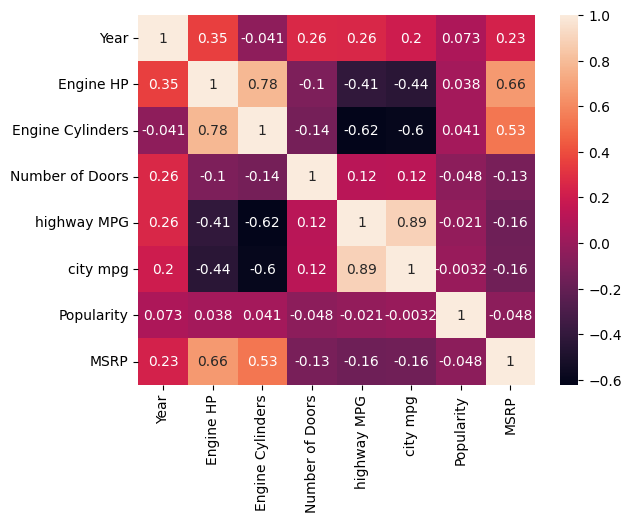

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

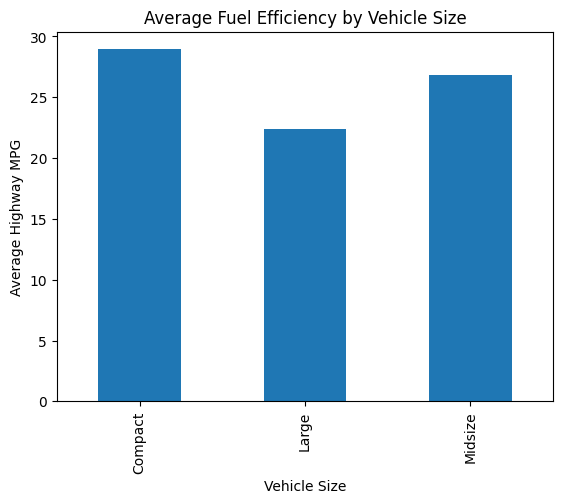

In [11]:
avg_mpg = df.groupby('Vehicle Size')['highway MPG'].mean()

avg_mpg.plot(kind='bar')
plt.title('Average Fuel Efficiency by Vehicle Size')
plt.xlabel('Vehicle Size')
plt.ylabel('Average Highway MPG')
plt.show()

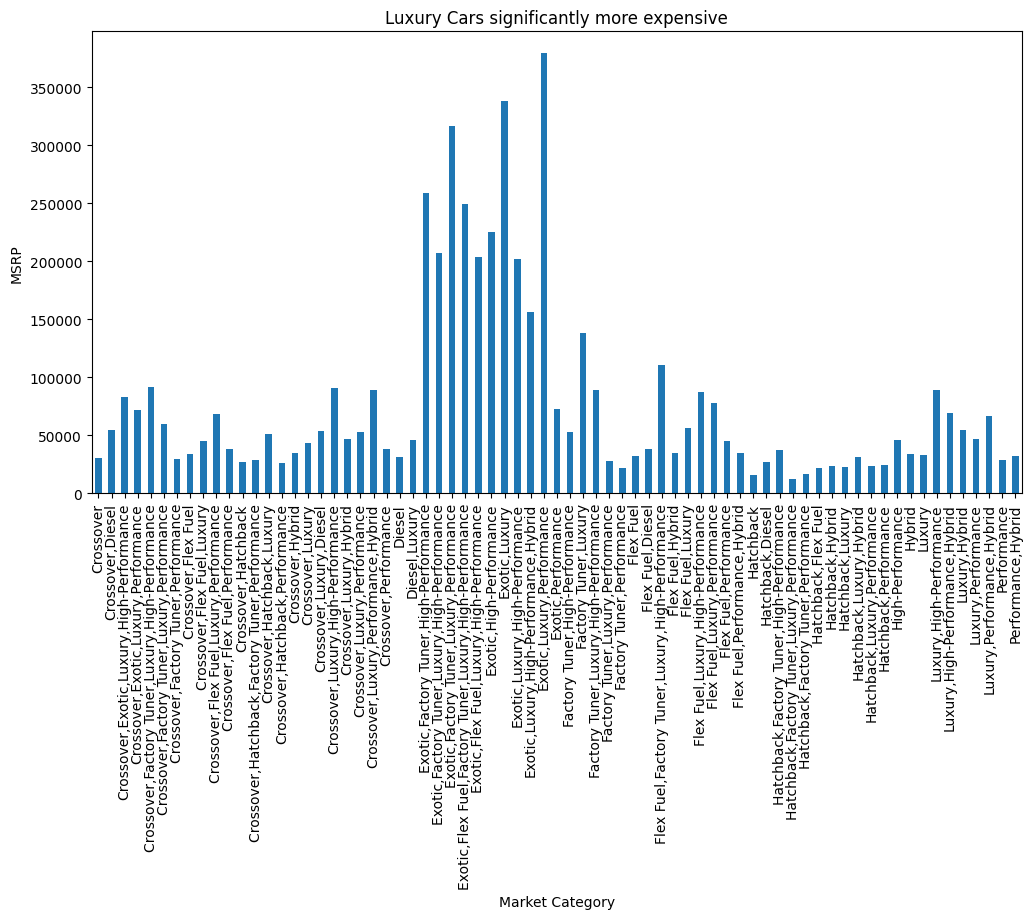

In [12]:
avg_mpg = df.groupby('Market Category')['MSRP'].mean()
avg_mpg.plot(kind='bar',figsize=(12,6))
plt.title('Luxury Cars significantly more expensive')
plt.xlabel('Market Category')
plt.ylabel('MSRP')
plt.show()

1)Do powerful engines lead to higher car prices?
>>Yes,Cars with higher engine horsepower generally have higher MSRP.
yes
Cars with higher engine horsepower generally have higher MSRP.

2)Does vehicle size affect fuel efficiency?
>>Yes. Compact vehicles tend to have better highway MPG than midsize and large vehicles.

3)Are luxury cars significantly more expensive?
>>Yes. Luxury market categories and premium vehicle styles show much higher MSRP values than standard vehicles.

4)Is there a relationship between popularity and price?
>>Only a weak relationship. A higher popularity score does not necessarily correspond to a higher MSRP.